In [1]:
</> Bash 
pip install pandas numpy openpyxl matplotlib seaborn

SyntaxError: invalid syntax (1545301921.py, line 1)

In [3]:
pip install pandas numpy openpyxl matplotlib seaborn statsmodels scikit-learn streamlit plotly

  Using cached statsmodels-0.15.0-cp313-cp313-win_amd64.whl.metadata (9.6 kB)
  Using cached streamlit-1.63.0-py3-none-any.whl.metadata (10 kB)
  Using cached formulaic-1.2.2-py3-none-any.whl.metadata (7.0 kB)
  Using cached altair-6.2.2-py3-none-any.whl.metadata (11 kB)
  Using cached pydeck-0.9.3-py2.py3-none-any.whl.metadata (4.2 kB)
  Using cached starlette-1.6.0-py3-none-any.whl.metadata (6.4 kB)
  Using cached anyio-4.14.2-py3-none-any.whl.metadata (4.6 kB)
  Using cached jinja2-3.1.6-py3-none-any.whl.metadata (2.9 kB)
Using cached statsmodels-0.15.0-cp313-cp313-win_amd64.whl (11.3 MB)
Using cached streamlit-1.63.0-py3-none-any.whl (10.5 MB)
Using cached altair-6.2.2-py3-none-any.whl (797 kB)
Using cached anyio-4.14.2-py3-none-any.whl (125 kB)
Using cached pydeck-0.9.3-py2.py3-none-any.whl (11.4 MB)
Using cached starlette-1.6.0-py3-none-any.whl (75 kB)
Using cached formulaic-1.2.2-py3-none-any.whl (118 kB)
Using cached jinja2-3.1.6-py3-none-any.whl (134 kB)

   ------------------

ERROR: Could not install packages due to an OSError: [WinError 32] The process cannot access the file because it is being used by another process: 'c:\\Users\\Adity\\Python\\Python313\\Lib\\site-packages\\pydeck\\data_utils\\viewport_helpers.py'
Consider using the `--user` option or check the permissions.


[notice] A new release of pip is available: 25.2 -> 26.2.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
import pandas as pd
import numpy as np
from pathlib import Path

print("Data Audit — Inflation Forecasting Dashboard")
print("Notebook initialized successfully.")

Data Audit — Inflation Forecasting Dashboard
Notebook initialized successfully.


In [7]:
from pathlib import Path

PROJECT_ROOT = Path("..")

RAW_CPI = PROJECT_ROOT / "data" / "raw" / "cpi"
RAW_WPI = PROJECT_ROOT / "data" / "raw" / "wpi"
RAW_PPI = PROJECT_ROOT / "data" / "raw" / "ppi"

PROCESSED = PROJECT_ROOT / "data" / "processed"

print("CPI folder:", RAW_CPI)
print("WPI folder:", RAW_WPI)
print("PPI folder:", RAW_PPI)
print("Processed folder:", PROCESSED)

CPI folder: ..\data\raw\cpi
WPI folder: ..\data\raw\wpi
PPI folder: ..\data\raw\ppi
Processed folder: ..\data\processed


In [11]:
import pandas as pd

cpi_hist = pd.read_csv("C:/Users/Adity/OneDrive/Desktop/RESEARCH/Project Work/Inflation-Forecasting-Dashboard/cpi_combined_historical_2012base.csv")

print(cpi_hist.shape)
print(cpi_hist.head())

(156, 12)
   baseyear  year  month_code      month      state    sector    group  \
0      2012  2025          12   December  All India  Combined  General   
1      2012  2025          11   November  All India  Combined  General   
2      2012  2025          10    October  All India  Combined  General   
3      2012  2025           9  September  All India  Combined  General   
4      2012  2025           8     August  All India  Combined  General   

          subgroup  index  inflation status  value  
0  General-Overall  198.0       1.33      F  198.0  
1  General-Overall  197.9       0.71      F  197.9  
2  General-Overall  197.3       0.25      F  197.3  
3  General-Overall  197.0       1.44      F  197.0  
4  General-Overall  197.0       2.07      F  197.0  


In [12]:
cpi_hist = pd.read_csv("C:/Users/Adity/OneDrive/Desktop/RESEARCH/Project Work/Inflation-Forecasting-Dashboard/cpi_combined_historical_2012base.csv")

In [13]:
import pandas as pd
import numpy as np
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [14]:
PROJECT_ROOT = Path("..")

RAW_CPI = PROJECT_ROOT / "data" / "raw" / "cpi"
RAW_WPI = PROJECT_ROOT / "data" / "raw" / "wpi"
RAW_PPI = PROJECT_ROOT / "data" / "raw" / "ppi"

PROCESSED = PROJECT_ROOT / "data" / "processed"

In [15]:
for folder in [RAW_CPI, RAW_WPI, RAW_PPI]:
    print(f"\n{folder}")
    for file in folder.glob("*"):
        print(" -", file.name)


..\data\raw\cpi

..\data\raw\wpi

..\data\raw\ppi


In [16]:
print(cpi_hist.columns.tolist())

['baseyear', 'year', 'month_code', 'month', 'state', 'sector', 'group', 'subgroup', 'index', 'inflation', 'status', 'value']


In [17]:
print("Base years:")
print(cpi_hist["baseyear"].unique())

print("\nStates:")
print(cpi_hist["state"].unique())

print("\nSectors:")
print(cpi_hist["sector"].unique())

print("\nGroups:")
print(cpi_hist["group"].unique())

print("\nSubgroups:")
print(cpi_hist["subgroup"].unique())

print("\nStatus:")
print(cpi_hist["status"].unique())

Base years:
[2012]

States:
['All India']

Sectors:
['Combined']

Groups:
['General']

Subgroups:
['General-Overall']

Status:
['F' 'F*']


In [18]:
print("Minimum year:", cpi_hist["year"].min())
print("Maximum year:", cpi_hist["year"].max())

Minimum year: 2013
Maximum year: 2025


In [19]:
cpi_hist["date"] = pd.to_datetime(
    cpi_hist["year"].astype(str) + "-" +
    cpi_hist["month_code"].astype(str) + "-01"
)

In [20]:
print("Start:", cpi_hist["date"].min())
print("End:", cpi_hist["date"].max())

Start: 2013-01-01 00:00:00
End: 2025-12-01 00:00:00


In [21]:
expected_dates = pd.date_range(
    start=cpi_hist["date"].min(),
    end=cpi_hist["date"].max(),
    freq="MS"
)

actual_dates = pd.DatetimeIndex(
    cpi_hist["date"].sort_values().unique()
)

missing_dates = expected_dates.difference(actual_dates)

print("Expected observations:", len(expected_dates))
print("Actual observations:", len(actual_dates))
print("Missing months:", len(missing_dates))

print(missing_dates)

Expected observations: 156
Actual observations: 156
Missing months: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='MS')


In [22]:
duplicate_dates = cpi_hist[
    cpi_hist["date"].duplicated(keep=False)
]

duplicate_dates
print("Duplicate dates:", cpi_hist["date"].duplicated().sum())

Duplicate dates: 0


In [23]:
cpi_hist.isna().sum()

baseyear       0
year           0
month_code     0
month          0
state          0
sector         0
group          0
subgroup       0
index          0
inflation     14
status         0
value          0
date           0
dtype: int64

In [24]:
print(cpi_hist["index"].dtype)

float64


In [26]:
cpi_hist["index"] = pd.to_numeric(
    cpi_hist["index"],
    errors="coerce"
)
print(cpi_hist["index"].dtype)

float64


In [27]:
print(cpi_hist["index"].describe())

count    156.000000
mean     150.054487
std       27.461274
min      104.600000
25%      127.125000
50%      143.550000
75%      175.400000
max      198.000000
Name: index, dtype: float64


In [28]:
print("Values <= 0:", (cpi_hist["index"] <= 0).sum())

Values <= 0: 0


In [29]:
print(cpi_hist["date"].head())

0   2025-12-01
1   2025-11-01
2   2025-10-01
3   2025-09-01
4   2025-08-01
Name: date, dtype: datetime64[ns]


In [30]:
cpi_hist = cpi_hist.sort_values("date").reset_index(drop=True)
print(cpi_hist[["date", "index"]].head())
print(cpi_hist[["date", "index"]].tail())

        date  index
0 2013-01-01  104.6
1 2013-02-01  105.3
2 2013-03-01  105.5
3 2013-04-01  106.1
4 2013-05-01  106.9
          date  index
151 2025-08-01  197.0
152 2025-09-01  197.0
153 2025-10-01  197.3
154 2025-11-01  197.9
155 2025-12-01  198.0


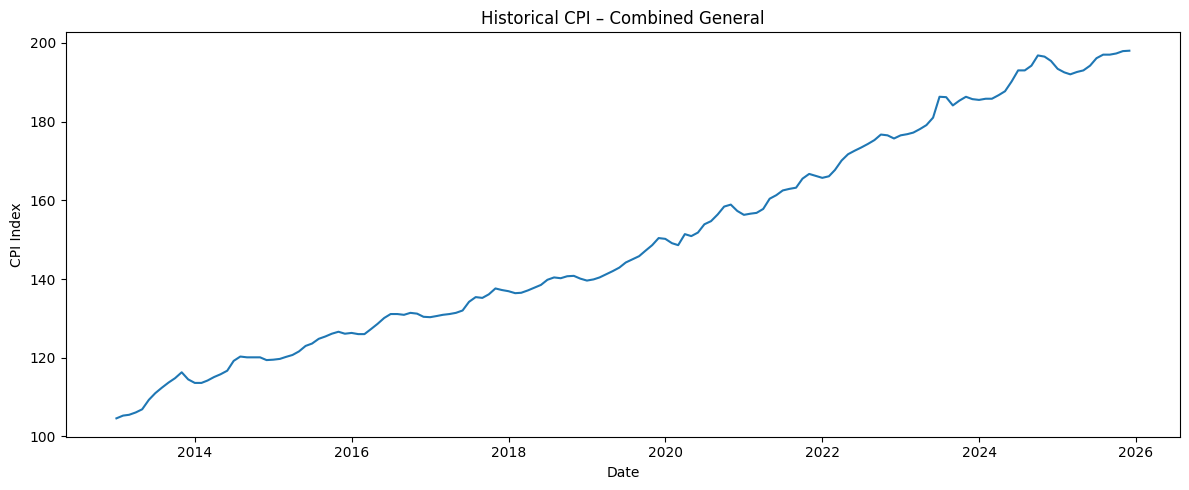

In [31]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))
plt.plot(cpi_hist["date"], cpi_hist["index"])
plt.title("Historical CPI – Combined General")
plt.xlabel("Date")
plt.ylabel("CPI Index")
plt.tight_layout()
plt.show()

In [32]:
cpi_hist["cpi_yoy"] = (
    cpi_hist["index"]
    .pct_change(periods=12)
    * 100
)
cpi_hist[["date", "index", "inflation", "cpi_yoy"]].tail(20)

,date,index,inflation,cpi_yoy
136,2024-05-01,187.7,4.80,4.801787
137,2024-06-01,190.2,5.08,5.082873
138,2024-07-01,193.0,3.60,3.596350
139,2024-08-01,193.0,3.65,3.651987
140,2024-09-01,194.2,5.49,5.486149
141,2024-10-01,196.8,6.21,6.206152
142,2024-11-01,196.5,5.48,5.475040
143,2024-12-01,195.4,5.22,5.223479
144,2025-01-01,193.4,4.26,4.258760
145,2025-02-01,192.5,3.61,3.606028


In [33]:
row = cpi_hist.loc[
    cpi_hist["date"] == "2025-12-01"
].iloc[0]

previous = cpi_hist.loc[
    cpi_hist["date"] == "2024-12-01"
].iloc[0]

manual = (
    (row["index"] / previous["index"]) - 1
) * 100

print("Calculated:", manual)
print("Stored YoY:", row["cpi_yoy"])

Calculated: 1.3306038894575156
Stored YoY: 1.3306038894575156


In [35]:
cpi_rural = pd.read_csv(
    RAW_CPI / "C:/Users/Adity/OneDrive/Desktop/RESEARCH/Project Work/Inflation-Forecasting-Dashboard/cpi_rural_current_2024base.csv"
)

In [37]:
cpi_urban = pd.read_csv(
    RAW_CPI / "C:/Users/Adity/OneDrive/Desktop/RESEARCH/Project Work/Inflation-Forecasting-Dashboard/cpi_urban_current_2024base.csv"
)

In [38]:
wpi = pd.read_excel(
    RAW_WPI / "C:/Users/Adity/OneDrive/Desktop/RESEARCH/Project Work/Inflation-Forecasting-Dashboard/wpi_monthly_2022_23base.xlsx",
    sheet_name=0
)

wpi.head()

,Level,Commodity Name,Commodity Code,Commodity Weight,Apr-23,May-23,Jun-23,Jul-23,Aug-23,Sep-23,Oct-23,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24,Sep-24,Oct-24,Nov-24,Dec-24,Jan-25,Feb-25,Mar-25,Apr-25,May-25,Jun-25,Jul-25,Aug-25,Sep-25,Oct-25,Nov-25,Dec-25,Jan-26,Feb-26,Mar-26,Apr-26,May-26,Jun-26,Jul-26
0,ALL,All Commodities,1.000000e+09,100.00000,99.0,98.6,98.3,99.1,99.5,99.6,100.1,100.1,99.4,99.3,99.3,99.4,99.9,100.4,100.7,101.0,100.8,101.2,102.1,102.1,101.6,101.1,100.9,100.6,100.5,100.2,100.3,100.2,100.8,101.0,100.9,101.5,101.9,102.3,103.1,104.6,108.9,110.1,110.2,110.0
1,Major Group,I PRIMARY ARTICLES,1.100000e+09,22.75730,102.0,102.3,103.3,107.9,108.0,106.4,107.8,108.9,107.2,107.4,107.9,108.1,108.8,110.1,111.8,113.1,113.8,115.4,117.1,117.1,115.2,112.2,109.8,108.6,108.5,108.3,108.5,108.0,109.6,110.7,110.4,112.3,112.0,112.1,111.6,111.4,112.8,114.0,116.1,117.2
2,Group,(A). FOOD ARTICLES,1.101000e+09,15.97835,102.4,103.6,105.8,111.3,111.3,108.6,110.5,112.5,110.3,109.7,110.4,110.5,112.1,114.0,116.5,118.2,119.1,121.2,123.0,122.5,119.8,115.4,112.2,111.1,111.3,111.0,111.2,112.1,112.9,113.0,112.6,115.2,114.5,113.9,113.1,112.8,114.2,115.1,117.3,118.2
3,Sub Group,a. Food Grains (Cereals+Pulses),1.101010e+09,3.60359,103.0,103.2,104.6,105.9,107.7,110.1,112.0,114.0,114.4,114.6,115.5,114.5,114.3,114.9,116.6,117.7,119.0,119.9,119.9,121.5,121.6,122.0,121.6,119.3,116.5,114.6,113.9,114.8,115.8,115.3,114.7,115.3,116.1,116.5,115.6,114.3,114.6,115.1,115.7,117.5
4,S_S_Group,a1. Cereals,1.101010e+09,3.03974,102.7,102.9,104.1,105.4,106.9,108.3,110.3,112.3,113.1,114.1,114.7,113.6,112.9,112.9,114.3,115.7,117.0,117.9,118.2,120.4,121.2,122.2,122.5,120.1,116.9,115.0,114.5,115.6,116.4,116.1,115.5,116.2,117.4,117.6,116.4,115.0,115.2,115.5,116.0,117.9


In [39]:
wpi.shape

(1137, 44)

In [40]:
wpi["Commodity Name"].head(30).to_list()
targets = [
    "All Commodities",
    "PRIMARY ARTICLES",
    "FUEL & POWER",
    "MANUFACTURED PRODUCTS"
]

for target in targets:
    print("\nTARGET:", target)
    print(
        wpi[
            wpi["Commodity Name"]
            .astype(str)
            .str.contains(target, case=False, na=False)
        ][
            ["Level", "Commodity Name", "Commodity Code", "Commodity Weight"]
        ]
    )


TARGET: All Commodities
  Level   Commodity Name  Commodity Code  Commodity Weight
0   ALL  All Commodities    1.000000e+09             100.0

TARGET: PRIMARY ARTICLES
         Level      Commodity Name  Commodity Code  Commodity Weight
1  Major Group  I PRIMARY ARTICLES    1.100000e+09           22.7573

TARGET: FUEL & POWER
           Level   Commodity Name  Commodity Code  Commodity Weight
152  Major Group  II FUEL & POWER    1.200000e+09          14.11433

TARGET: MANUFACTURED PRODUCTS
           Level              Commodity Name  Commodity Code  Commodity Weight
190  Major Group  III. MANUFACTURED PRODUCTS    1.300000e+09          63.12837


In [41]:
month_columns = wpi.columns[4:]

print(month_columns.tolist())

['Apr-23', 'May-23', 'Jun-23', 'Jul-23', 'Aug-23', 'Sep-23', 'Oct-23', 'Nov-23', 'Dec-23', 'Jan-24', 'Feb-24', 'Mar-24', 'Apr-24', 'May-24', 'Jun-24', 'Jul-24', 'Aug-24', 'Sep-24', 'Oct-24', 'Nov-24', 'Dec-24', 'Jan-25', 'Feb-25', 'Mar-25', 'Apr-25', 'May-25', 'Jun-25', 'Jul-25', 'Aug-25', 'Sep-25', 'Oct-25', 'Nov-25', 'Dec-25', 'Jan-26', 'Feb-26', 'Mar-26', 'Apr-26', 'May-26', 'Jun-26', 'Jul-26']


In [42]:
print("Number of monthly columns:", len(month_columns))

Number of monthly columns: 40


In [43]:
wpi_dates = pd.to_datetime(
    month_columns,
    format="%b-%y"
)

print(wpi_dates.min())
print(wpi_dates.max())

2023-04-01 00:00:00
2026-07-01 00:00:00


In [44]:
wpi_core = wpi[
    wpi["Commodity Name"].astype(str).str.contains(
        "All Commodities|PRIMARY ARTICLES|FUEL & POWER|MANUFACTURED PRODUCTS",
        case=False,
        regex=True,
        na=False
    )
]

wpi_core[month_columns].isna().sum(axis=1)

0      0
1      0
152    0
190    0
dtype: int64

In [45]:
wpi_core[
    ["Commodity Name", "Commodity Weight"]
]

,Commodity Name,Commodity Weight
0,All Commodities,100.00000
1,I PRIMARY ARTICLES,22.75730
152,II FUEL & POWER,14.11433
190,III. MANUFACTURED PRODUCTS,63.12837


In [49]:
ppi = pd.read_excel(
    RAW_PPI / "C:/Users/Adity/OneDrive/Desktop/RESEARCH/Project Work/Inflation-Forecasting-Dashboard/output_ppi_monthly_2022_23base.xlsx",
    sheet_name=0
)

In [50]:
ppi.shape
ppi.head()

,Level,Commodity Code,Commodity Name,Commodity Weight,Apr-23,May-23,Jun-23,Jul-23,Aug-23,Sep-23,Oct-23,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24,Sep-24,Oct-24,Nov-24,Dec-24,Jan-25,Feb-25,Mar-25,Apr-25,May-25,Jun-25,Jul-25,Aug-25,Sep-25,Oct-25,Nov-25,Dec-25,Jan-26,Feb-26,Mar-26,Apr-26,May-26,Jun-26,Jul-26
0,All,1000000000,ALL COMMODITIES,100.00000,99.1,98.6,98.2,99.1,99.4,99.6,100.0,99.9,99.2,99.2,99.2,99.2,99.7,100.1,100.4,100.8,100.7,101.0,101.8,102.0,101.5,101.2,101.0,100.7,100.5,100.2,100.3,100.3,100.9,101.0,101.1,101.7,102.1,102.6,103.3,104.9,108.8,109.9,109.9,109.9
1,Major Group,1100000000,"AGRICULTURE, FORESTRY AND FISHING",22.15648,102.4,102.5,103.4,107.4,107.8,106.9,108.0,108.9,107.0,106.9,106.9,107.1,107.6,108.4,109.8,111.3,112.1,113.8,115.1,115.2,113.9,111.3,109.2,107.8,107.5,107.0,107.1,107.2,108.6,109.4,109.6,111.5,111.3,111.3,110.8,110.6,111.4,112.1,114.1,115.6
2,Group,1101000000,"CROP AND ANIMAL PRODUCTION, HUNTING AND RELATE...",19.03219,102.5,102.2,103.3,108.0,108.3,107.7,108.9,110.2,107.9,107.1,107.1,107.4,107.7,108.3,110.1,112.2,112.6,114.6,116.2,116.3,114.8,111.6,109.2,107.9,107.6,106.5,106.6,108.3,109.5,109.6,109.8,112.1,111.9,111.7,111.3,111.0,111.5,111.9,114.3,116.1
3,SUT Product Category,1101010000,Paddy,1.57272,104.7,106.0,107.6,109.9,110.7,112.5,114.6,115.9,116.9,118.5,119.5,119.0,118.7,118.4,119.6,120.6,121.1,121.0,120.0,121.6,122.0,121.1,121.0,120.5,119.5,117.4,116.8,118.0,117.9,118.0,118.1,119.7,121.4,121.0,120.9,120.4,119.3,119.6,120.4,121.7
4,SUT Product Category,1101020000,Wheat,0.96605,99.2,98.7,100.5,100.4,103.1,104.6,107.1,109.7,110.0,109.9,109.9,108.0,106.0,106.0,107.9,109.4,111.7,114.0,117.7,121.3,122.8,126.4,127.5,121.1,114.1,112.3,111.5,113.1,115.4,115.0,114.4,114.2,114.5,116.2,113.5,110.8,113.4,113.4,112.4,114.4


In [51]:
ppi[ppi["Commodity Name"].astype(str).str.contains(
    "ALL COMMODITIES",
    case=False,
    na=False
)]

,Level,Commodity Code,Commodity Name,Commodity Weight,Apr-23,May-23,Jun-23,Jul-23,Aug-23,Sep-23,Oct-23,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24,Sep-24,Oct-24,Nov-24,Dec-24,Jan-25,Feb-25,Mar-25,Apr-25,May-25,Jun-25,Jul-25,Aug-25,Sep-25,Oct-25,Nov-25,Dec-25,Jan-26,Feb-26,Mar-26,Apr-26,May-26,Jun-26,Jul-26
0,All,1000000000,ALL COMMODITIES,100.0,99.1,98.6,98.2,99.1,99.4,99.6,100.0,99.9,99.2,99.2,99.2,99.2,99.7,100.1,100.4,100.8,100.7,101.0,101.8,102.0,101.5,101.2,101.0,100.7,100.5,100.2,100.3,100.3,100.9,101.0,101.1,101.7,102.1,102.6,103.3,104.9,108.8,109.9,109.9,109.9


In [52]:
ppi_months = ppi.columns[4:]

print("Start:", ppi_months[0])
print("End:", ppi_months[-1])
print("Months:", len(ppi_months))
ppi_core = ppi[
    ppi["Commodity Name"].astype(str).str.contains(
        "ALL COMMODITIES",
        case=False,
        na=False
    )
]

ppi_core[ppi_months].isna().sum(axis=1)

Start: Apr-23
End: Jul-26
Months: 40


0    0
dtype: int64

In [57]:
audit_report = pd.DataFrame([
    {
        "Dataset": "CPI Historical Combined",
        "Start": cpi_hist["date"].min(),
        "End": cpi_hist["date"].max(),
        "Observations": len(cpi_hist),
        "Frequency": "Monthly",
        "Base Year": "2012",
        "Missing Index": cpi_hist["index"].isna().sum(),
        "Duplicate Dates": cpi_hist["date"].duplicated().sum(),
    }
])

audit_report

,Dataset,Start,End,Observations,Frequency,Base Year,Missing Index,Duplicate Dates
0,CPI Historical Combined,2013-01-01,2025-12-01,156,Monthly,2012,0,0


In [55]:
cpi_hist["index_change_pct"] = (
    cpi_hist["index"].pct_change() * 100
)

cpi_hist[
    cpi_hist["index_change_pct"].abs() > 5
]

,baseyear,year,month_code,month,state,sector,group,subgroup,index,inflation,status,value,date,cpi_yoy,index_change_pct


In [56]:
print(cpi_hist.shape)
print(cpi_hist.columns.tolist())
print(cpi_hist.dtypes)
print(cpi_hist[["baseyear","state","sector","group","subgroup","status"]].drop_duplicates())
print(cpi_hist.isna().sum())

(156, 15)
['baseyear', 'year', 'month_code', 'month', 'state', 'sector', 'group', 'subgroup', 'index', 'inflation', 'status', 'value', 'date', 'cpi_yoy', 'index_change_pct']
baseyear                     int64
year                         int64
month_code                   int64
month                       object
state                       object
sector                      object
group                       object
subgroup                    object
index                      float64
inflation                  float64
status                      object
value                      float64
date                datetime64[ns]
cpi_yoy                    float64
index_change_pct           float64
dtype: object
    baseyear      state    sector    group         subgroup status
0       2012  All India  Combined  General  General-Overall      F
87      2012  All India  Combined  General  General-Overall     F*
baseyear             0
year                 0
month_code           0
month            

In [58]:
print(audit_report)

                   Dataset      Start        End  Observations Frequency  \
0  CPI Historical Combined 2013-01-01 2025-12-01           156   Monthly   

  Base Year  Missing Index  Duplicate Dates  
0      2012              0                0  


In [59]:
audit_report

,Dataset,Start,End,Observations,Frequency,Base Year,Missing Index,Duplicate Dates
0,CPI Historical Combined,2013-01-01,2025-12-01,156,Monthly,2012,0,0


In [60]:
audit_report.style

,Dataset,Start,End,Observations,Frequency,Base Year,Missing Index,Duplicate Dates
0,CPI Historical Combined,2013-01-01 00:00:00,2025-12-01 00:00:00,156,Monthly,2012,0,0


In [61]:
cpi_rural = pd.read_csv("C:/Users/Adity/OneDrive/Desktop/RESEARCH/Project Work/Inflation-Forecasting-Dashboard/cpi_rural_current_2024base.csv")

In [62]:
print("Shape:", cpi_rural.shape)

print("\nColumns:")
print(cpi_rural.columns.tolist())

print("\nData Types:")
print(cpi_rural.dtypes)

print("\nMetadata:")
print(
    cpi_rural[
        ["base_year", "state", "sector", "division", "group"]
    ].drop_duplicates()
)

print("\nMissing Values:")
print(cpi_rural.isna().sum())

print("\nYear Range:")
print(cpi_rural["year"].min(), "to", cpi_rural["year"].max())

print("\nMonth Range:")
print(cpi_rural["month"].unique())

Shape: (19, 18)

Columns:
['base_year', 'month_code', 'series', 'year', 'month', 'state', 'sector', 'division', 'group', 'class', 'sub_class', 'item', 'code', 'weight', 'index', 'inflation', 'imputation', 'value']

Data Types:
base_year       int64
month_code      int64
series         object
year            int64
month          object
state          object
sector         object
division       object
group         float64
class         float64
sub_class     float64
item          float64
code          float64
weight        float64
index         float64
inflation     float64
imputation    float64
value         float64
dtype: object

Metadata:
   base_year      state sector       division  group
0       2024  All India  Rural  CPI (General)    NaN

Missing Values:
base_year      0
month_code     0
series         0
year           0
month          0
state          0
sector         0
division       0
group         19
class         19
sub_class     19
item          19
code          19
weight  

In [63]:
cpi_rural["date"] = pd.to_datetime(
    cpi_rural["year"].astype(str)
    + "-"
    + cpi_rural["month_code"].astype(str)
    + "-01"
)

cpi_rural = cpi_rural.sort_values("date").reset_index(drop=True)

print("\nExact Start:", cpi_rural["date"].min())
print("Exact End:", cpi_rural["date"].max())


Exact Start: 2025-01-01 00:00:00
Exact End: 2026-07-01 00:00:00


In [64]:
expected_dates = pd.date_range(
    start=cpi_rural["date"].min(),
    end=cpi_rural["date"].max(),
    freq="MS"
)

actual_dates = pd.DatetimeIndex(
    cpi_rural["date"].unique()
)

missing_dates = expected_dates.difference(actual_dates)

print("\nExpected Months:", len(expected_dates))
print("Actual Months:", len(actual_dates))
print("Missing Months:", len(missing_dates))
print(missing_dates)


Expected Months: 19
Actual Months: 19
Missing Months: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='MS')


In [65]:
print(
    "\nDuplicate Dates:",
    cpi_rural["date"].duplicated().sum()
)


Duplicate Dates: 0


In [66]:
cpi_urban = pd.read_csv("C:/Users/Adity/OneDrive/Desktop/RESEARCH\Project Work/Inflation-Forecasting-Dashboard/cpi_urban_current_2024base.csv")

print("Shape:", cpi_urban.shape)

Shape: (19, 18)


<>:1: SyntaxWarning: invalid escape sequence '\P'
<>:1: SyntaxWarning: invalid escape sequence '\P'
C:\Users\Adity\AppData\Local\Temp\ipykernel_19816\4111187835.py:1: SyntaxWarning: invalid escape sequence '\P'
  cpi_urban = pd.read_csv("C:/Users/Adity/OneDrive/Desktop/RESEARCH\Project Work/Inflation-Forecasting-Dashboard/cpi_urban_current_2024base.csv")


In [67]:
print("\nColumns:")
print(cpi_urban.columns.tolist())

print("\nData Types:")
print(cpi_urban.dtypes)

print("\nMetadata:")
print(
    cpi_urban[
        ["base_year", "state", "sector", "division", "group"]
    ].drop_duplicates()
)

print("\nMissing Values:")
print(cpi_urban.isna().sum())


Columns:
['base_year', 'month_code', 'series', 'year', 'month', 'state', 'sector', 'division', 'group', 'class', 'sub_class', 'item', 'code', 'weight', 'index', 'inflation', 'imputation', 'value']

Data Types:
base_year       int64
month_code      int64
series         object
year            int64
month          object
state          object
sector         object
division       object
group         float64
class         float64
sub_class     float64
item          float64
code          float64
weight        float64
index         float64
inflation     float64
imputation    float64
value         float64
dtype: object

Metadata:
   base_year      state sector       division  group
0       2024  All India  Urban  CPI (General)    NaN

Missing Values:
base_year      0
month_code     0
series         0
year           0
month          0
state          0
sector         0
division       0
group         19
class         19
sub_class     19
item          19
code          19
weight         0
index  

In [68]:
cpi_urban["date"] = pd.to_datetime(
    cpi_urban["year"].astype(str)
    + "-"
    + cpi_urban["month_code"].astype(str)
    + "-01"
)

cpi_urban = cpi_urban.sort_values("date").reset_index(drop=True)

print("Start:", cpi_urban["date"].min())
print("End:", cpi_urban["date"].max())

Start: 2025-01-01 00:00:00
End: 2026-07-01 00:00:00


In [69]:
expected_dates = pd.date_range(
    start=cpi_urban["date"].min(),
    end=cpi_urban["date"].max(),
    freq="MS"
)

actual_dates = pd.DatetimeIndex(
    cpi_urban["date"].unique()
)

missing_dates = expected_dates.difference(actual_dates)

print("Expected Months:", len(expected_dates))
print("Actual Months:", len(actual_dates))
print("Missing Months:", len(missing_dates))
print(missing_dates)

Expected Months: 19
Actual Months: 19
Missing Months: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='MS')


In [70]:
print(
    "Duplicate Dates:",
    cpi_urban["date"].duplicated().sum()
)

Duplicate Dates: 0


In [71]:
print(cpi_urban["index"].describe())

print(
    "Non-positive index values:",
    (cpi_urban["index"] <= 0).sum()
)

count     19.000000
mean     103.721579
std        1.724353
min      101.300000
25%      102.360000
50%      103.660000
75%      104.490000
max      107.450000
Name: index, dtype: float64
Non-positive index values: 0


In [74]:
audit_report = pd.DataFrame([
    {
        "Dataset": "CPI Urban",
        "Start": cpi_urban["date"].min(),
        "End": cpi_urban["date"].max(),
        "Observations": len(cpi_urban),
        "Frequency": "Monthly",
        "Base Year": "2024",
        "Missing Index": cpi_urban["index"].isna().sum(),
        "Duplicate Dates": cpi_urban["date"].duplicated().sum(),
    }
])

audit_report

,Dataset,Start,End,Observations,Frequency,Base Year,Missing Index,Duplicate Dates
0,CPI Urban,2025-01-01,2026-07-01,19,Monthly,2024,0,0


In [75]:
audit_report.style

,Dataset,Start,End,Observations,Frequency,Base Year,Missing Index,Duplicate Dates
0,CPI Urban,2025-01-01 00:00:00,2026-07-01 00:00:00,19,Monthly,2024,0,0


In [76]:
audit_report = pd.DataFrame([
    {
        "Dataset": "CPI Rural",
        "Start": cpi_rural["date"].min(),
        "End": cpi_rural["date"].max(),
        "Observations": len(cpi_rural),
        "Frequency": "Monthly",
        "Base Year": "2024",
        "Missing Index": cpi_rural["index"].isna().sum(),
        "Duplicate Dates": cpi_rural["date"].duplicated().sum(),
    }
])

audit_report

,Dataset,Start,End,Observations,Frequency,Base Year,Missing Index,Duplicate Dates
0,CPI Rural,2025-01-01,2026-07-01,19,Monthly,2024,0,0


In [77]:
audit_report.style

,Dataset,Start,End,Observations,Frequency,Base Year,Missing Index,Duplicate Dates
0,CPI Rural,2025-01-01 00:00:00,2026-07-01 00:00:00,19,Monthly,2024,0,0


In [78]:
cpi_food = pd.read_csv("C:/Users/Adity/OneDrive/Desktop/RESEARCH/Project Work/Inflation-Forecasting-Dashboard/CombinedCFPI_database.csv")

In [79]:
print("Shape:", cpi_food.shape)

print("\nColumns:")
print(cpi_food.columns.tolist())

print("\nData Types:")
print(cpi_food.dtypes)

Shape: (19, 18)

Columns:
['base_year', 'month_code', 'series', 'year', 'month', 'state', 'sector', 'division', 'group', 'class', 'sub_class', 'item', 'code', 'weight', 'index', 'inflation', 'imputation', 'value']

Data Types:
base_year       int64
month_code      int64
series         object
year            int64
month          object
state          object
sector         object
division       object
group          object
class         float64
sub_class     float64
item          float64
code          float64
weight        float64
index         float64
inflation     float64
imputation    float64
value         float64
dtype: object


In [80]:
print("\nMetadata:")
print(
    cpi_food[
        ["base_year", "state", "sector", "division", "group"]
    ].drop_duplicates()
)


Metadata:
   base_year      state sector            division group
0       2024  All India  Rural  Food and beverages  Food


In [81]:
print("\nMissing Values:")
print(cpi_food.isna().sum())


Missing Values:
base_year      0
month_code     0
series         0
year           0
month          0
state          0
sector         0
division       0
group          0
class         19
sub_class     19
item          19
code           0
weight         0
index          0
inflation     12
imputation    19
value          0
dtype: int64


In [82]:
cpi_food["date"] = pd.to_datetime(
    cpi_food["year"].astype(str)
    + "-"
    + cpi_food["month_code"].astype(str)
    + "-01"
)

cpi_food = cpi_food.sort_values("date").reset_index(drop=True)

print("\nStart:", cpi_food["date"].min())
print("End:", cpi_food["date"].max())


Start: 2025-01-01 00:00:00
End: 2026-07-01 00:00:00


In [83]:
expected_dates = pd.date_range(
    start=cpi_food["date"].min(),
    end=cpi_food["date"].max(),
    freq="MS"
)

actual_dates = pd.DatetimeIndex(
    cpi_food["date"].unique()
)

missing_dates = expected_dates.difference(actual_dates)

print("\nExpected Months:", len(expected_dates))
print("Actual Months:", len(actual_dates))
print("Missing Months:", len(missing_dates))
print(missing_dates)


Expected Months: 19
Actual Months: 19
Missing Months: 0
DatetimeIndex([], dtype='datetime64[ns]', freq='MS')


In [84]:
print(
    "Duplicate Dates:",
    cpi_food["date"].duplicated().sum()
)

Duplicate Dates: 0


In [85]:
print("\nIndex Description:")
print(cpi_food["index"].describe())

print(
    "Non-positive index values:",
    (cpi_food["index"] <= 0).sum()
)


Index Description:
count     19.000000
mean     103.370526
std        2.377367
min       99.910000
25%      101.595000
50%      103.840000
75%      104.240000
max      109.210000
Name: index, dtype: float64
Non-positive index values: 0


In [86]:
audit_food = pd.DataFrame([
    {
        "Dataset": "CPI Food",
        "Start": cpi_food["date"].min(),
        "End": cpi_food["date"].max(),
        "Observations": len(cpi_food),
        "Frequency": "Monthly",
        "Base Year": cpi_food["base_year"].iloc[0],
        "Missing Index": cpi_food["index"].isna().sum(),
        "Duplicate Dates": cpi_food["date"].duplicated().sum(),
    }
])

audit_food

,Dataset,Start,End,Observations,Frequency,Base Year,Missing Index,Duplicate Dates
0,CPI Food,2025-01-01,2026-07-01,19,Monthly,2024,0,0


In [87]:
cpi_food[
    ["base_year", "state", "sector", "division", "group"]
].drop_duplicates()

,base_year,state,sector,division,group
0,2024,All India,Rural,Food and beverages,Food


In [88]:
audit_report.style

,Dataset,Start,End,Observations,Frequency,Base Year,Missing Index,Duplicate Dates
0,CPI Rural,2025-01-01 00:00:00,2026-07-01 00:00:00,19,Monthly,2024,0,0


In [91]:
import pandas as pd

wpi = pd.read_excel(
    r"C:\Users\Adity\OneDrive\Desktop\RESEARCH\Project Work\Inflation-Forecasting-Dashboard\wpi_monthly_2022_23base.xlsx",
    sheet_name="Sheet3",
    engine="openpyxl"
)

print("Shape:", wpi.shape)
display(wpi.head(10))

Shape: (1137, 44)


,Level,Commodity Name,Commodity Code,Commodity Weight,Apr-23,May-23,Jun-23,Jul-23,Aug-23,Sep-23,Oct-23,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24,Sep-24,Oct-24,Nov-24,Dec-24,Jan-25,Feb-25,Mar-25,Apr-25,May-25,Jun-25,Jul-25,Aug-25,Sep-25,Oct-25,Nov-25,Dec-25,Jan-26,Feb-26,Mar-26,Apr-26,May-26,Jun-26,Jul-26
0,ALL,All Commodities,1.000000e+09,100.00000,99.0,98.6,98.3,99.1,99.5,99.6,100.1,100.1,99.4,99.3,99.3,99.4,99.9,100.4,100.7,101.0,100.8,101.2,102.1,102.1,101.6,101.1,100.9,100.6,100.5,100.2,100.3,100.2,100.8,101.0,100.9,101.5,101.9,102.3,103.1,104.6,108.9,110.1,110.2,110.0
1,Major Group,I PRIMARY ARTICLES,1.100000e+09,22.75730,102.0,102.3,103.3,107.9,108.0,106.4,107.8,108.9,107.2,107.4,107.9,108.1,108.8,110.1,111.8,113.1,113.8,115.4,117.1,117.1,115.2,112.2,109.8,108.6,108.5,108.3,108.5,108.0,109.6,110.7,110.4,112.3,112.0,112.1,111.6,111.4,112.8,114.0,116.1,117.2
2,Group,(A). FOOD ARTICLES,1.101000e+09,15.97835,102.4,103.6,105.8,111.3,111.3,108.6,110.5,112.5,110.3,109.7,110.4,110.5,112.1,114.0,116.5,118.2,119.1,121.2,123.0,122.5,119.8,115.4,112.2,111.1,111.3,111.0,111.2,112.1,112.9,113.0,112.6,115.2,114.5,113.9,113.1,112.8,114.2,115.1,117.3,118.2
3,Sub Group,a. Food Grains (Cereals+Pulses),1.101010e+09,3.60359,103.0,103.2,104.6,105.9,107.7,110.1,112.0,114.0,114.4,114.6,115.5,114.5,114.3,114.9,116.6,117.7,119.0,119.9,119.9,121.5,121.6,122.0,121.6,119.3,116.5,114.6,113.9,114.8,115.8,115.3,114.7,115.3,116.1,116.5,115.6,114.3,114.6,115.1,115.7,117.5
4,S_S_Group,a1. Cereals,1.101010e+09,3.03974,102.7,102.9,104.1,105.4,106.9,108.3,110.3,112.3,113.1,114.1,114.7,113.6,112.9,112.9,114.3,115.7,117.0,117.9,118.2,120.4,121.2,122.2,122.5,120.1,116.9,115.0,114.5,115.6,116.4,116.1,115.5,116.2,117.4,117.6,116.4,115.0,115.2,115.5,116.0,117.9
5,Item,Paddy,1.101010e+09,1.59243,104.7,106.0,107.6,109.9,110.7,112.5,114.6,115.9,116.9,118.5,119.5,119.0,118.7,118.4,119.6,120.6,121.1,121.0,120.0,121.6,122.0,121.1,121.0,120.5,119.5,117.4,116.8,118.0,117.9,118.0,118.1,119.7,121.4,121.0,120.9,120.4,119.3,119.6,120.4,121.7
6,Item,Wheat,1.101010e+09,0.97815,99.2,98.7,100.5,100.4,103.1,104.6,107.1,109.7,110.0,109.9,109.9,108.0,106.0,106.0,107.9,109.4,111.7,114.0,117.7,121.3,122.8,126.4,127.5,121.1,114.1,112.3,111.5,113.1,115.4,115.0,114.4,114.2,114.5,116.2,113.5,110.8,113.4,113.4,112.4,114.4
7,Item,Maize,1.101010e+09,0.30700,101.5,98.7,96.9,97.8,99.2,99.1,99.2,101.1,102.0,104.9,105.6,104.2,104.8,106.3,108.3,111.7,114.6,116.1,113.0,113.2,113.9,116.1,116.5,116.0,113.4,111.8,112.5,112.3,113.4,110.9,107.3,105.7,105.8,104.3,102.1,100.0,99.7,101.6,105.1,110.0
8,Item,Bajra,1.101010e+09,0.09004,107.8,105.8,103.6,102.2,103.1,101.8,104.3,110.8,111.3,111.0,110.5,110.1,110.1,109.9,108.6,110.4,111.6,111.9,113.6,117.3,119.4,122.0,120.9,118.5,115.2,113.9,111.7,111.0,110.8,111.9,110.1,112.6,114.9,114.2,112.7,110.6,108.4,107.7,106.2,108.6
9,Item,Jowar,1.101010e+09,0.04147,111.7,111.2,114.6,120.8,123.5,125.6,124.9,128.8,132.9,127.5,124.0,121.1,119.4,117.8,116.6,116.3,112.6,112.8,110.0,111.0,109.1,109.1,110.9,111.7,112.0,111.4,112.0,110.9,109.9,108.9,107.1,111.0,114.3,117.7,120.4,121.7,122.2,120.4,125.3,126.1


In [92]:
print("Shape:", wpi.shape)
print("\nColumns:")
print(wpi.columns.tolist())
display(wpi.head(10))

Shape: (1137, 44)

Columns:
['Level', 'Commodity Name', 'Commodity Code', 'Commodity Weight', 'Apr-23', 'May-23', 'Jun-23', 'Jul-23', 'Aug-23', 'Sep-23', 'Oct-23', 'Nov-23', 'Dec-23', 'Jan-24', 'Feb-24', 'Mar-24', 'Apr-24', 'May-24', 'Jun-24', 'Jul-24', 'Aug-24', 'Sep-24', 'Oct-24', 'Nov-24', 'Dec-24', 'Jan-25', 'Feb-25', 'Mar-25', 'Apr-25', 'May-25', 'Jun-25', 'Jul-25', 'Aug-25', 'Sep-25', 'Oct-25', 'Nov-25', 'Dec-25', 'Jan-26', 'Feb-26', 'Mar-26', 'Apr-26', 'May-26', 'Jun-26', 'Jul-26']


,Level,Commodity Name,Commodity Code,Commodity Weight,Apr-23,May-23,Jun-23,Jul-23,Aug-23,Sep-23,Oct-23,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24,Sep-24,Oct-24,Nov-24,Dec-24,Jan-25,Feb-25,Mar-25,Apr-25,May-25,Jun-25,Jul-25,Aug-25,Sep-25,Oct-25,Nov-25,Dec-25,Jan-26,Feb-26,Mar-26,Apr-26,May-26,Jun-26,Jul-26
0,ALL,All Commodities,1.000000e+09,100.00000,99.0,98.6,98.3,99.1,99.5,99.6,100.1,100.1,99.4,99.3,99.3,99.4,99.9,100.4,100.7,101.0,100.8,101.2,102.1,102.1,101.6,101.1,100.9,100.6,100.5,100.2,100.3,100.2,100.8,101.0,100.9,101.5,101.9,102.3,103.1,104.6,108.9,110.1,110.2,110.0
1,Major Group,I PRIMARY ARTICLES,1.100000e+09,22.75730,102.0,102.3,103.3,107.9,108.0,106.4,107.8,108.9,107.2,107.4,107.9,108.1,108.8,110.1,111.8,113.1,113.8,115.4,117.1,117.1,115.2,112.2,109.8,108.6,108.5,108.3,108.5,108.0,109.6,110.7,110.4,112.3,112.0,112.1,111.6,111.4,112.8,114.0,116.1,117.2
2,Group,(A). FOOD ARTICLES,1.101000e+09,15.97835,102.4,103.6,105.8,111.3,111.3,108.6,110.5,112.5,110.3,109.7,110.4,110.5,112.1,114.0,116.5,118.2,119.1,121.2,123.0,122.5,119.8,115.4,112.2,111.1,111.3,111.0,111.2,112.1,112.9,113.0,112.6,115.2,114.5,113.9,113.1,112.8,114.2,115.1,117.3,118.2
3,Sub Group,a. Food Grains (Cereals+Pulses),1.101010e+09,3.60359,103.0,103.2,104.6,105.9,107.7,110.1,112.0,114.0,114.4,114.6,115.5,114.5,114.3,114.9,116.6,117.7,119.0,119.9,119.9,121.5,121.6,122.0,121.6,119.3,116.5,114.6,113.9,114.8,115.8,115.3,114.7,115.3,116.1,116.5,115.6,114.3,114.6,115.1,115.7,117.5
4,S_S_Group,a1. Cereals,1.101010e+09,3.03974,102.7,102.9,104.1,105.4,106.9,108.3,110.3,112.3,113.1,114.1,114.7,113.6,112.9,112.9,114.3,115.7,117.0,117.9,118.2,120.4,121.2,122.2,122.5,120.1,116.9,115.0,114.5,115.6,116.4,116.1,115.5,116.2,117.4,117.6,116.4,115.0,115.2,115.5,116.0,117.9
5,Item,Paddy,1.101010e+09,1.59243,104.7,106.0,107.6,109.9,110.7,112.5,114.6,115.9,116.9,118.5,119.5,119.0,118.7,118.4,119.6,120.6,121.1,121.0,120.0,121.6,122.0,121.1,121.0,120.5,119.5,117.4,116.8,118.0,117.9,118.0,118.1,119.7,121.4,121.0,120.9,120.4,119.3,119.6,120.4,121.7
6,Item,Wheat,1.101010e+09,0.97815,99.2,98.7,100.5,100.4,103.1,104.6,107.1,109.7,110.0,109.9,109.9,108.0,106.0,106.0,107.9,109.4,111.7,114.0,117.7,121.3,122.8,126.4,127.5,121.1,114.1,112.3,111.5,113.1,115.4,115.0,114.4,114.2,114.5,116.2,113.5,110.8,113.4,113.4,112.4,114.4
7,Item,Maize,1.101010e+09,0.30700,101.5,98.7,96.9,97.8,99.2,99.1,99.2,101.1,102.0,104.9,105.6,104.2,104.8,106.3,108.3,111.7,114.6,116.1,113.0,113.2,113.9,116.1,116.5,116.0,113.4,111.8,112.5,112.3,113.4,110.9,107.3,105.7,105.8,104.3,102.1,100.0,99.7,101.6,105.1,110.0
8,Item,Bajra,1.101010e+09,0.09004,107.8,105.8,103.6,102.2,103.1,101.8,104.3,110.8,111.3,111.0,110.5,110.1,110.1,109.9,108.6,110.4,111.6,111.9,113.6,117.3,119.4,122.0,120.9,118.5,115.2,113.9,111.7,111.0,110.8,111.9,110.1,112.6,114.9,114.2,112.7,110.6,108.4,107.7,106.2,108.6
9,Item,Jowar,1.101010e+09,0.04147,111.7,111.2,114.6,120.8,123.5,125.6,124.9,128.8,132.9,127.5,124.0,121.1,119.4,117.8,116.6,116.3,112.6,112.8,110.0,111.0,109.1,109.1,110.9,111.7,112.0,111.4,112.0,110.9,109.9,108.9,107.1,111.0,114.3,117.7,120.4,121.7,122.2,120.4,125.3,126.1


In [93]:
print(
    wpi[
        ["Level", "Commodity Name", "Commodity Code", "Commodity Weight"]
    ].head(30)
)

          Level                    Commodity Name  Commodity Code  \
0           ALL                   All Commodities    1.000000e+09   
1   Major Group                I PRIMARY ARTICLES    1.100000e+09   
2         Group                (A). FOOD ARTICLES    1.101000e+09   
3     Sub Group  a. Food Grains (Cereals+Pulses)     1.101010e+09   
4     S_S_Group                       a1. Cereals    1.101010e+09   
5          Item                             Paddy    1.101010e+09   
6          Item                             Wheat    1.101010e+09   
7          Item                             Maize    1.101010e+09   
8          Item                             Bajra    1.101010e+09   
9          Item                             Jowar    1.101010e+09   
10         Item                              Ragi    1.101010e+09   
11         Item                            Barley    1.101010e+09   
12    S_S_Group                        a2. Pulses    1.101010e+09   
13         Item                   

In [94]:
targets = [
    "All Commodities",
    "PRIMARY ARTICLES",
    "FUEL & POWER",
    "MANUFACTURED PRODUCTS"
]

for target in targets:
    print("\n---", target, "---")
    
    result = wpi[
        wpi["Commodity Name"]
        .astype(str)
        .str.contains(target, case=False, na=False)
    ]
    
    display(
        result[
            ["Level", "Commodity Name", "Commodity Code", "Commodity Weight"]
        ]
    )


--- All Commodities ---


,Level,Commodity Name,Commodity Code,Commodity Weight
0,ALL,All Commodities,1.000000e+09,100.0



--- PRIMARY ARTICLES ---


,Level,Commodity Name,Commodity Code,Commodity Weight
1,Major Group,I PRIMARY ARTICLES,1.100000e+09,22.7573



--- FUEL & POWER ---


,Level,Commodity Name,Commodity Code,Commodity Weight
152,Major Group,II FUEL & POWER,1.200000e+09,14.11433



--- MANUFACTURED PRODUCTS ---


,Level,Commodity Name,Commodity Code,Commodity Weight
190,Major Group,III. MANUFACTURED PRODUCTS,1.300000e+09,63.12837


In [95]:
month_columns = wpi.columns[4:]

print("First month:", month_columns[0])
print("Last month:", month_columns[-1])
print("Number of month columns:", len(month_columns))

First month: Apr-23
Last month: Jul-26
Number of month columns: 40


In [97]:
wpi_core = wpi[
    wpi["Commodity Name"].astype(str).str.contains(
        "All Commodities|PRIMARY ARTICLES|FUEL & POWER|MANUFACTURED PRODUCTS",
        case=False,
        regex=True,
        na=False
    )
]

display(
    wpi_core[
        ["Commodity Name", "Commodity Weight"]
    ]
)

print("\nMissing values by series:")

for _, row in wpi_core.iterrows():
    print(
        row["Commodity Name"],
        "→",
        row[month_columns].isna().sum(),
        "missing"
    )

,Commodity Name,Commodity Weight
0,All Commodities,100.00000
1,I PRIMARY ARTICLES,22.75730
152,II FUEL & POWER,14.11433
190,III. MANUFACTURED PRODUCTS,63.12837



Missing values by series:
All Commodities → 0 missing
I PRIMARY ARTICLES → 0 missing
II FUEL & POWER → 0 missing
III. MANUFACTURED PRODUCTS → 0 missing


In [98]:
import pandas as pd

wpi = pd.read_excel(
    r"C:\Users\Adity\OneDrive\Desktop\RESEARCH\Project Work\Inflation-Forecasting-Dashboard\wpi_monthly_2022_23base.xlsx",
    sheet_name="Sheet3"
)

print("Shape:", wpi.shape)
print("\nColumns:")
print(wpi.columns.tolist())
display(wpi.head(10))

Shape: (1137, 44)

Columns:
['Level', 'Commodity Name', 'Commodity Code', 'Commodity Weight', 'Apr-23', 'May-23', 'Jun-23', 'Jul-23', 'Aug-23', 'Sep-23', 'Oct-23', 'Nov-23', 'Dec-23', 'Jan-24', 'Feb-24', 'Mar-24', 'Apr-24', 'May-24', 'Jun-24', 'Jul-24', 'Aug-24', 'Sep-24', 'Oct-24', 'Nov-24', 'Dec-24', 'Jan-25', 'Feb-25', 'Mar-25', 'Apr-25', 'May-25', 'Jun-25', 'Jul-25', 'Aug-25', 'Sep-25', 'Oct-25', 'Nov-25', 'Dec-25', 'Jan-26', 'Feb-26', 'Mar-26', 'Apr-26', 'May-26', 'Jun-26', 'Jul-26']


,Level,Commodity Name,Commodity Code,Commodity Weight,Apr-23,May-23,Jun-23,Jul-23,Aug-23,Sep-23,Oct-23,Nov-23,Dec-23,Jan-24,Feb-24,Mar-24,Apr-24,May-24,Jun-24,Jul-24,Aug-24,Sep-24,Oct-24,Nov-24,Dec-24,Jan-25,Feb-25,Mar-25,Apr-25,May-25,Jun-25,Jul-25,Aug-25,Sep-25,Oct-25,Nov-25,Dec-25,Jan-26,Feb-26,Mar-26,Apr-26,May-26,Jun-26,Jul-26
0,ALL,All Commodities,1.000000e+09,100.00000,99.0,98.6,98.3,99.1,99.5,99.6,100.1,100.1,99.4,99.3,99.3,99.4,99.9,100.4,100.7,101.0,100.8,101.2,102.1,102.1,101.6,101.1,100.9,100.6,100.5,100.2,100.3,100.2,100.8,101.0,100.9,101.5,101.9,102.3,103.1,104.6,108.9,110.1,110.2,110.0
1,Major Group,I PRIMARY ARTICLES,1.100000e+09,22.75730,102.0,102.3,103.3,107.9,108.0,106.4,107.8,108.9,107.2,107.4,107.9,108.1,108.8,110.1,111.8,113.1,113.8,115.4,117.1,117.1,115.2,112.2,109.8,108.6,108.5,108.3,108.5,108.0,109.6,110.7,110.4,112.3,112.0,112.1,111.6,111.4,112.8,114.0,116.1,117.2
2,Group,(A). FOOD ARTICLES,1.101000e+09,15.97835,102.4,103.6,105.8,111.3,111.3,108.6,110.5,112.5,110.3,109.7,110.4,110.5,112.1,114.0,116.5,118.2,119.1,121.2,123.0,122.5,119.8,115.4,112.2,111.1,111.3,111.0,111.2,112.1,112.9,113.0,112.6,115.2,114.5,113.9,113.1,112.8,114.2,115.1,117.3,118.2
3,Sub Group,a. Food Grains (Cereals+Pulses),1.101010e+09,3.60359,103.0,103.2,104.6,105.9,107.7,110.1,112.0,114.0,114.4,114.6,115.5,114.5,114.3,114.9,116.6,117.7,119.0,119.9,119.9,121.5,121.6,122.0,121.6,119.3,116.5,114.6,113.9,114.8,115.8,115.3,114.7,115.3,116.1,116.5,115.6,114.3,114.6,115.1,115.7,117.5
4,S_S_Group,a1. Cereals,1.101010e+09,3.03974,102.7,102.9,104.1,105.4,106.9,108.3,110.3,112.3,113.1,114.1,114.7,113.6,112.9,112.9,114.3,115.7,117.0,117.9,118.2,120.4,121.2,122.2,122.5,120.1,116.9,115.0,114.5,115.6,116.4,116.1,115.5,116.2,117.4,117.6,116.4,115.0,115.2,115.5,116.0,117.9
5,Item,Paddy,1.101010e+09,1.59243,104.7,106.0,107.6,109.9,110.7,112.5,114.6,115.9,116.9,118.5,119.5,119.0,118.7,118.4,119.6,120.6,121.1,121.0,120.0,121.6,122.0,121.1,121.0,120.5,119.5,117.4,116.8,118.0,117.9,118.0,118.1,119.7,121.4,121.0,120.9,120.4,119.3,119.6,120.4,121.7
6,Item,Wheat,1.101010e+09,0.97815,99.2,98.7,100.5,100.4,103.1,104.6,107.1,109.7,110.0,109.9,109.9,108.0,106.0,106.0,107.9,109.4,111.7,114.0,117.7,121.3,122.8,126.4,127.5,121.1,114.1,112.3,111.5,113.1,115.4,115.0,114.4,114.2,114.5,116.2,113.5,110.8,113.4,113.4,112.4,114.4
7,Item,Maize,1.101010e+09,0.30700,101.5,98.7,96.9,97.8,99.2,99.1,99.2,101.1,102.0,104.9,105.6,104.2,104.8,106.3,108.3,111.7,114.6,116.1,113.0,113.2,113.9,116.1,116.5,116.0,113.4,111.8,112.5,112.3,113.4,110.9,107.3,105.7,105.8,104.3,102.1,100.0,99.7,101.6,105.1,110.0
8,Item,Bajra,1.101010e+09,0.09004,107.8,105.8,103.6,102.2,103.1,101.8,104.3,110.8,111.3,111.0,110.5,110.1,110.1,109.9,108.6,110.4,111.6,111.9,113.6,117.3,119.4,122.0,120.9,118.5,115.2,113.9,111.7,111.0,110.8,111.9,110.1,112.6,114.9,114.2,112.7,110.6,108.4,107.7,106.2,108.6
9,Item,Jowar,1.101010e+09,0.04147,111.7,111.2,114.6,120.8,123.5,125.6,124.9,128.8,132.9,127.5,124.0,121.1,119.4,117.8,116.6,116.3,112.6,112.8,110.0,111.0,109.1,109.1,110.9,111.7,112.0,111.4,112.0,110.9,109.9,108.9,107.1,111.0,114.3,117.7,120.4,121.7,122.2,120.4,125.3,126.1


In [99]:
targets = [
    "All Commodities",
    "PRIMARY ARTICLES",
    "FUEL & POWER",
    "MANUFACTURED PRODUCTS"
]

for target in targets:
    print("\n---", target, "---")
    
    result = wpi[
        wpi["Commodity Name"]
        .astype(str)
        .str.contains(target, case=False, na=False)
    ]
    
    display(
        result[
            ["Level", "Commodity Name", "Commodity Code", "Commodity Weight"]
        ]
    )


--- All Commodities ---


,Level,Commodity Name,Commodity Code,Commodity Weight
0,ALL,All Commodities,1.000000e+09,100.0



--- PRIMARY ARTICLES ---


,Level,Commodity Name,Commodity Code,Commodity Weight
1,Major Group,I PRIMARY ARTICLES,1.100000e+09,22.7573



--- FUEL & POWER ---


,Level,Commodity Name,Commodity Code,Commodity Weight
152,Major Group,II FUEL & POWER,1.200000e+09,14.11433



--- MANUFACTURED PRODUCTS ---


,Level,Commodity Name,Commodity Code,Commodity Weight
190,Major Group,III. MANUFACTURED PRODUCTS,1.300000e+09,63.12837


In [100]:
month_columns = wpi.columns[4:]

print("First month:", month_columns[0])
print("Last month:", month_columns[-1])
print("Number of month columns:", len(month_columns))

First month: Apr-23
Last month: Jul-26
Number of month columns: 40


In [101]:
wpi_core = wpi[
    wpi["Commodity Name"].astype(str).str.contains(
        "All Commodities|PRIMARY ARTICLES|FUEL & POWER|MANUFACTURED PRODUCTS",
        case=False,
        regex=True,
        na=False
    )
]

display(
    wpi_core[
        ["Level", "Commodity Name", "Commodity Code", "Commodity Weight"]
    ]
)

print("\nMissing values:")

for _, row in wpi_core.iterrows():
    print(
        row["Commodity Name"],
        "→",
        row[month_columns].isna().sum(),
        "missing"
    )

,Level,Commodity Name,Commodity Code,Commodity Weight
0,ALL,All Commodities,1.000000e+09,100.00000
1,Major Group,I PRIMARY ARTICLES,1.100000e+09,22.75730
152,Major Group,II FUEL & POWER,1.200000e+09,14.11433
190,Major Group,III. MANUFACTURED PRODUCTS,1.300000e+09,63.12837



Missing values:
All Commodities → 0 missing
I PRIMARY ARTICLES → 0 missing
II FUEL & POWER → 0 missing
III. MANUFACTURED PRODUCTS → 0 missing


In [102]:
print(ppi.columns.tolist())

['Level', 'Commodity Code', 'Commodity Name', 'Commodity Weight', 'Apr-23', 'May-23', 'Jun-23', 'Jul-23', 'Aug-23', 'Sep-23', 'Oct-23', 'Nov-23', 'Dec-23', 'Jan-24', 'Feb-24', 'Mar-24', 'Apr-24', 'May-24', 'Jun-24', 'Jul-24', 'Aug-24', 'Sep-24', 'Oct-24', 'Nov-24', 'Dec-24', 'Jan-25', 'Feb-25', 'Mar-25', 'Apr-25', 'May-25', 'Jun-25', 'Jul-25', 'Aug-25', 'Sep-25', 'Oct-25', 'Nov-25', 'Dec-25', 'Jan-26', 'Feb-26', 'Mar-26', 'Apr-26', 'May-26', 'Jun-26', 'Jul-26']


In [103]:
print("\nLevels:")
print(ppi["Level"].dropna().unique())

print("\nFirst 20 commodity names:")
print(ppi["Commodity Name"].head(20).tolist())


Levels:
['All' 'Major Group' 'Group' 'SUT Product Category']

First 20 commodity names:
['ALL COMMODITIES', 'AGRICULTURE, FORESTRY AND FISHING', 'CROP AND ANIMAL PRODUCTION, HUNTING AND RELATED SERVICE ACTIVITIES', 'Paddy', 'Wheat', 'Coarse Cereals', 'Gram', 'Arhar', 'Other Pulses', 'Groundnut', 'Rapeseed And Mustard', 'Other Oil Seeds', 'Fibre Crop', 'Sugar Crop', 'Coconut', 'Tobacco', 'Tea', 'Coffee', 'Rubber', 'Mango ']


In [104]:
ppi[
    ppi["Commodity Name"]
    .astype(str)
    .str.contains(
        "ALL COMMODITIES",
        case=False,
        na=False
    )
][
    ["Level", "Commodity Code", "Commodity Name", "Commodity Weight"]
]

,Level,Commodity Code,Commodity Name,Commodity Weight
0,All,1000000000,ALL COMMODITIES,100.0


In [105]:
ppi_month_columns = ppi.columns[4:]

print("First month:", ppi_month_columns[0])
print("Last month:", ppi_month_columns[-1])
print("Number of monthly observations:", len(ppi_month_columns))

First month: Apr-23
Last month: Jul-26
Number of monthly observations: 40


In [106]:
ppi_dates = pd.to_datetime(
    ppi_month_columns,
    format="%b-%y"
)

print("Start:", ppi_dates.min())
print("End:", ppi_dates.max())

Start: 2023-04-01 00:00:00
End: 2026-07-01 00:00:00


In [107]:
expected_ppi_dates = pd.date_range(
    start=ppi_dates.min(),
    end=ppi_dates.max(),
    freq="MS"
)

missing_ppi_dates = expected_ppi_dates.difference(ppi_dates)

print("Expected months:", len(expected_ppi_dates))
print("Actual months:", len(ppi_dates))
print("Missing months:", len(missing_ppi_dates))
print("Missing dates:", missing_ppi_dates)

Expected months: 40
Actual months: 40
Missing months: 0
Missing dates: DatetimeIndex([], dtype='datetime64[ns]', freq='MS')


In [108]:
ppi_all = ppi[
    ppi["Commodity Name"]
    .astype(str)
    .str.fullmatch(
        "ALL COMMODITIES",
        case=False,
        na=False
    )
].copy()

In [109]:
print("Number of ALL COMMODITIES rows:", len(ppi_all))

Number of ALL COMMODITIES rows: 1


In [110]:
print(
    "Missing observations:",
    ppi_all[ppi_month_columns].isna().sum().sum()
)

Missing observations: 0


In [111]:
display(
    ppi_all[
        ["Level", "Commodity Code", "Commodity Name", "Commodity Weight"]
    ]
)

,Level,Commodity Code,Commodity Name,Commodity Weight
0,All,1000000000,ALL COMMODITIES,100.0


In [112]:
ppi_values = ppi_all[ppi_month_columns].apply(
    pd.to_numeric,
    errors="coerce"
)

print(ppi_values.describe())
print(
    "Non-positive values:",
    (ppi_values <= 0).sum().sum()
)

       Apr-23  May-23  Jun-23  Jul-23  Aug-23  Sep-23  Oct-23  Nov-23  Dec-23  \
count     1.0     1.0     1.0     1.0     1.0     1.0     1.0     1.0     1.0   
mean     99.1    98.6    98.2    99.1    99.4    99.6   100.0    99.9    99.2   
std       NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN     NaN   
min      99.1    98.6    98.2    99.1    99.4    99.6   100.0    99.9    99.2   
25%      99.1    98.6    98.2    99.1    99.4    99.6   100.0    99.9    99.2   
50%      99.1    98.6    98.2    99.1    99.4    99.6   100.0    99.9    99.2   
75%      99.1    98.6    98.2    99.1    99.4    99.6   100.0    99.9    99.2   
max      99.1    98.6    98.2    99.1    99.4    99.6   100.0    99.9    99.2   

       Jan-24  Feb-24  Mar-24  Apr-24  May-24  Jun-24  Jul-24  Aug-24  Sep-24  \
count     1.0     1.0     1.0     1.0     1.0     1.0     1.0     1.0     1.0   
mean     99.2    99.2    99.2    99.7   100.1   100.4   100.8   100.7   101.0   
std       NaN     NaN     N

In [113]:
ppi_series = ppi_values.iloc[0].astype(float)

ppi_mom_change = ppi_series.pct_change() * 100

print(ppi_mom_change.describe())
display(
    pd.DataFrame({
        "Month": ppi_month_columns,
        "Index": ppi_series.values,
        "MoM_Change_%": ppi_mom_change.values
    })
)

count    39.000000
mean      0.268123
std       0.727370
min      -0.700701
25%      -0.099603
50%       0.099800
75%       0.445661
max       3.717827
Name: 0, dtype: float64


,Month,Index,MoM_Change_%
0,Apr-23,99.1,NaN
1,May-23,98.6,-0.504541
2,Jun-23,98.2,-0.405680
3,Jul-23,99.1,0.916497
4,Aug-23,99.4,0.302725
5,Sep-23,99.6,0.201207
6,Oct-23,100.0,0.401606
7,Nov-23,99.9,-0.100000
8,Dec-23,99.2,-0.700701
9,Jan-24,99.2,0.000000


In [114]:
ppi_series.index = ppi_dates

ppi_yoy = ppi_series.pct_change(12) * 100

ppi_yoy_df = pd.DataFrame({
    "date": ppi_dates,
    "ppi_index": ppi_series.values,
    "ppi_yoy": ppi_yoy.values
})

display(ppi_yoy_df.tail(20))

,date,ppi_index,ppi_yoy
20,2024-12-01,101.5,2.318548
21,2025-01-01,101.2,2.016129
22,2025-02-01,101.0,1.814516
23,2025-03-01,100.7,1.512097
24,2025-04-01,100.5,0.802407
25,2025-05-01,100.2,0.099900
26,2025-06-01,100.3,-0.099602
27,2025-07-01,100.3,-0.496032
28,2025-08-01,100.9,0.198610
29,2025-09-01,101.0,0.000000


In [115]:
date_diff = pd.Series(ppi_dates).diff().dropna()

print(date_diff.value_counts())

31 days    22
30 days    14
28 days     2
29 days     1
Name: count, dtype: int64


In [116]:
audit_ppi = pd.DataFrame([
    {
        "Dataset": "Output PPI",
        "Start": ppi_dates.min(),
        "End": ppi_dates.max(),
        "Observations": len(ppi_dates),
        "Frequency": "Monthly",
        "Base Year": "2022-23",
        "Missing Index": int(ppi_all[ppi_month_columns].isna().sum().sum()),
        "Duplicate Aggregate Rows": len(ppi_all) - 1,
    }
])

audit_ppi

,Dataset,Start,End,Observations,Frequency,Base Year,Missing Index,Duplicate Aggregate Rows
0,Output PPI,2023-04-01,2026-07-01,40,Monthly,2022-23,0,0


In [117]:
print("========== OUTPUT PPI FINAL AUDIT ==========")

print("Rows:", ppi.shape[0])
print("Columns:", ppi.shape[1])

print("Start:", ppi_dates.min())
print("End:", ppi_dates.max())

print("Monthly observations:", len(ppi_dates))

print(
    "Missing months:",
    len(missing_ppi_dates)
)

print(
    "Missing headline PPI values:",
    int(ppi_all[ppi_month_columns].isna().sum().sum())
)

print(
    "Headline aggregate rows:",
    len(ppi_all)
)

print(
    "Headline weight:",
    ppi_all["Commodity Weight"].iloc[0]
)

print("============================================")

========== OUTPUT PPI FINAL AUDIT ==========
Rows: 161
Columns: 44
Start: 2023-04-01 00:00:00
End: 2026-07-01 00:00:00
Monthly observations: 40
Missing months: 0
Missing headline PPI values: 0
Headline aggregate rows: 1
Headline weight: 100.0
